# **08_comparacion_modelos**
Responsable: Daniel


1. Cargar dataset

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
import pandas as pd

df = pd.read_csv(
    "dataset_limpio.csv",
    index_col=0
)

print(df.shape)

(117922, 37)


 2. Crear y_bin

En el notebook ***notebooks/07_baseline_decision_tree.ipynb*** esta construido, pero no esta guardado en ***data/processed/dataset_limpio.csv***, tambien lo construimos aqui

In [31]:
NORMAL_CLASSES = {
    "MQTT_Publish",
    "Thing_Speak",
    "Wipro_bulb"
}

y_bin = (
    ~df["Attack_type"].isin(NORMAL_CLASSES)
).astype(int)

In [32]:
print(y_bin.value_counts())

Attack_type
1    105907
0     12015
Name: count, dtype: int64


3. Preparacion de X



In [33]:
X = df.drop(
    columns=["Attack_type"]
)

4. Eliminación de Variables Leaky

In [34]:
LEAKY = [
    "id.orig_p",
    "id.resp_p",
    "proto",
    "service"
]

X = X.drop(
    columns=LEAKY
)

5. División Train/Test (80/20)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_bin,
    test_size=0.20,
    random_state=42,
    stratify=y_bin
)

In [36]:
print("Forma de Train:", X_train.shape)
print("Forma de Test:", X_test.shape)

print("\nDistribución en Train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución en Test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Forma de Train: (94337, 32)
Forma de Test: (23585, 32)

Distribución en Train (%):
Attack_type
1    89.81
0    10.19
Name: proportion, dtype: float64

Distribución en Test (%):
Attack_type
1    89.81
0    10.19
Name: proportion, dtype: float64


6. Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

7. Logistic Regression

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

8. KNN

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5
    ))
])

9. SVM

In [40]:
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ))
])

11. Entrenarlos y medir tiempos

In [41]:
import time

def evaluar_modelo(nombre, modelo):

    inicio = time.perf_counter()

    modelo.fit(
        X_train,
        y_train
    )

    tiempo_train = time.perf_counter() - inicio

    inicio = time.perf_counter()

    y_pred = modelo.predict(X_test)

    tiempo_pred = time.perf_counter() - inicio

    y_prob = modelo.predict_proba(X_test)[:, 1]

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(
            y_test, y_pred
        ),
        "Precision": precision_score(
            y_test, y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test, y_pred,
            zero_division=0
        ),
        "F1-Macro": f1_score(
            y_test, y_pred,
            average="macro",
            zero_division=0
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        ),
        "Tiempo entrenamiento": tiempo_train,
        "Tiempo predicción": tiempo_pred
    }, y_pred, y_prob

In [52]:
modelos = {
    "Random Forest": rf,
    "Logistic Regression": lr,
    "KNN": knn,
    "SVM": svm
}

resultados = []
predicciones = {}
probabilidades = {}
modelos_entrenados = {}

for nombre, modelo in modelos.items():

    print(f"Entrenando {nombre}...")

    resultado, y_pred, y_prob = evaluar_modelo(
        nombre,
        modelo
    )

    resultados.append(resultado)
    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_prob
    modelos_entrenados[nombre] = modelo
    print(f"-> {nombre} finalizado.")

Entrenando Random Forest...
-> Random Forest finalizado.
Entrenando Logistic Regression...
-> Logistic Regression finalizado.
Entrenando KNN...
-> KNN finalizado.
Entrenando SVM...
-> SVM finalizado.


12. Crear la tabla

In [43]:
resultados_df = pd.DataFrame(resultados)
resultados_df

,Modelo,Accuracy,Precision,Recall,F1-score,F1-Macro,PR-AUC,Tiempo entrenamiento,Tiempo predicción
0,Random Forest,0.998516,0.998868,0.999481,0.999174,0.995936,0.999754,4.548698,0.201508
1,Logistic Regression,0.963155,0.997892,0.961005,0.979101,0.911809,0.999142,3.925369,0.020992
2,KNN,0.997286,0.997644,0.999339,0.998491,0.992537,0.999324,0.157614,15.919036
3,SVM,0.982319,0.998751,0.981541,0.990071,0.954715,0.999620,924.609392,5.381365


In [59]:
baseline= {
    "Modelo": "Decision Tree Baseline ",
    "Accuracy": 0.9983,
    "Precision": 0.9989,
    "Recall": 0.9992,
    "F1-score": 0.9990,
    "F1-Macro": 0.9952,
    "PR-AUC": 0.9988,
    "Tiempo entrenamiento": 0.4080,
    "Tiempo predicción": 0.0115
}

resultados_df = pd.concat([pd.DataFrame([baseline]), resultados_df], ignore_index=True)
resultados_df.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,F1-Macro,PR-AUC,Tiempo entrenamiento,Tiempo predicción
0,Decision Tree Baseline,0.9983,0.9989,0.9992,0.9990,0.9952,0.9988,0.4080,0.0115
1,Random Forest,0.9985,0.9989,0.9995,0.9992,0.9959,0.9998,4.7942,0.2273
2,Logistic Regression,0.9632,0.9979,0.9610,0.9791,0.9118,0.9991,6.4682,0.0427
3,KNN,0.9973,0.9976,0.9993,0.9985,0.9925,0.9993,0.1712,20.9587
4,SVM,0.9823,0.9988,0.9815,0.9901,0.9547,0.9996,963.4717,5.3502


13. Matriz de confusion

In [45]:
from sklearn.metrics import confusion_matrix

for nombre, y_pred in predicciones.items():

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    print(
        nombre,
        "TN:", tn,
        "FP:", fp,
        "FN:", fn,
        "TP:", tp
    )

Random Forest TN: 2379 FP: 24 FN: 11 TP: 21171
Logistic Regression TN: 2360 FP: 43 FN: 826 TP: 20356
KNN TN: 2353 FP: 50 FN: 14 TP: 21168
SVM TN: 2377 FP: 26 FN: 391 TP: 20791


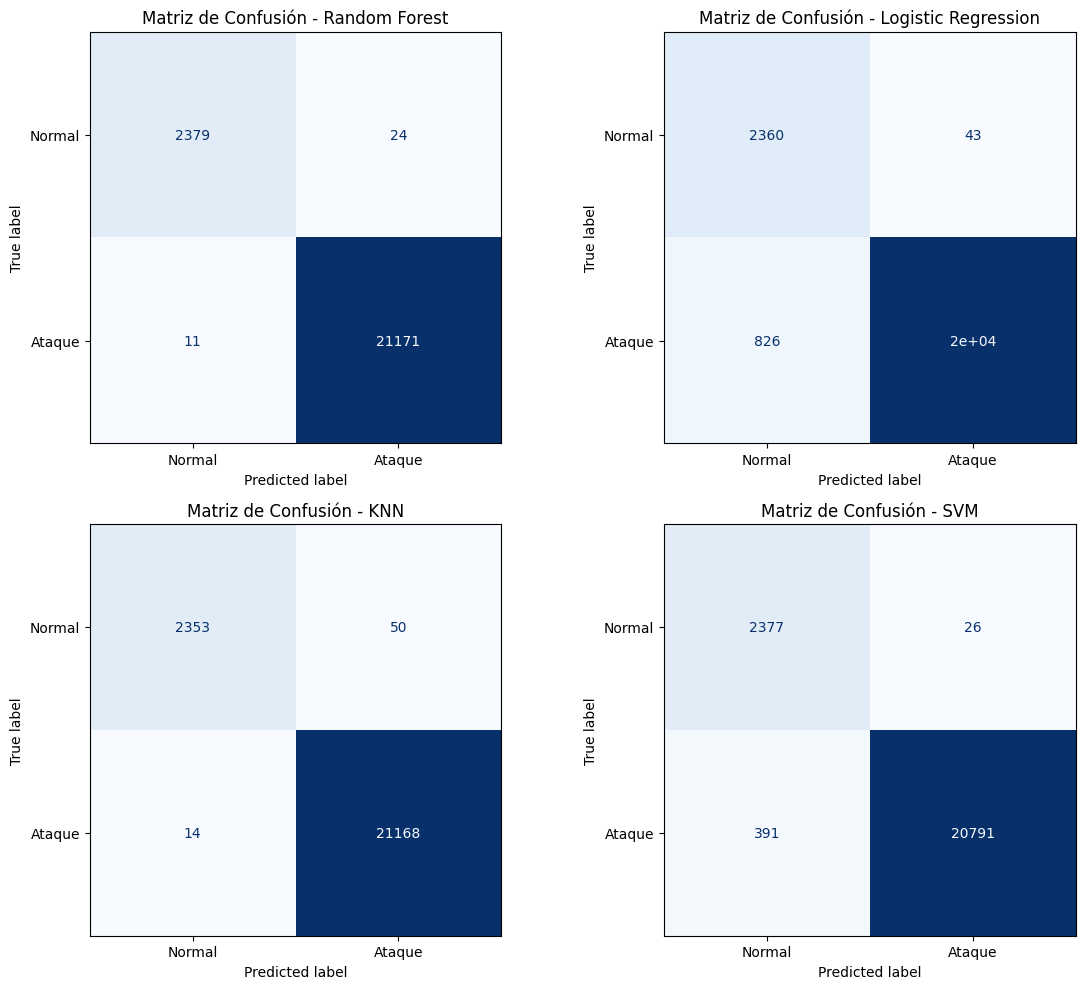

In [46]:

import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import CalibrationDisplay
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (nombre, y_pred) in enumerate(predicciones.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Normal", "Ataque"],
        ax=axes[idx],
        cmap="Blues",
        colorbar=False
    )
    axes[idx].set_title(f"Matriz de Confusión - {nombre}")

plt.tight_layout()
plt.show()

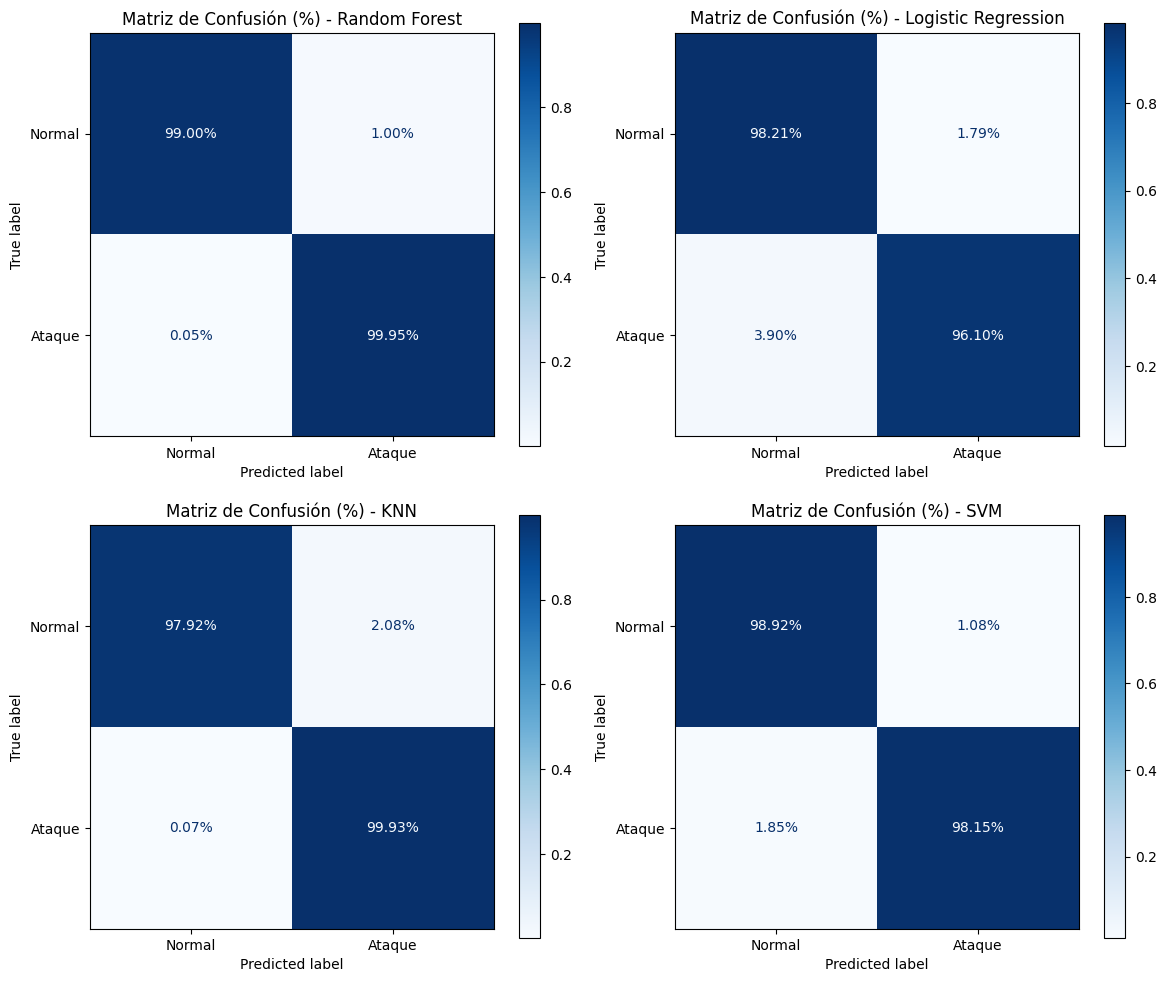

In [58]:
# ==========================================
# MATRICES DE CONFUSIÓN EN PORCENTAJES (%)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (nombre, modelo) in enumerate(modelos_entrenados.items()):
    # normalize='true' calcula los porcentajes por cada clase real (filas)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predicciones[nombre],
        display_labels=["Normal", "Ataque"],
        ax=axes[idx],
        cmap="Blues",
        values_format=".2%",
        normalize="true"
    )
    axes[idx].set_title(f"Matriz de Confusión (%) - {nombre}")

plt.tight_layout()
plt.show()

14. Precision-Recall

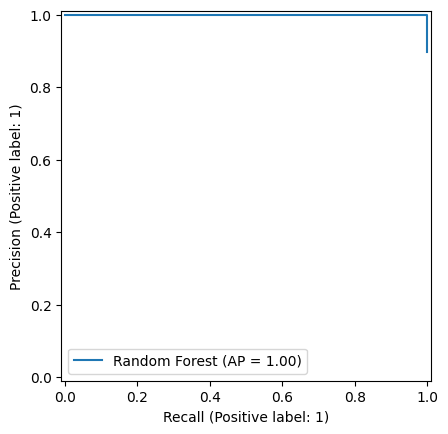

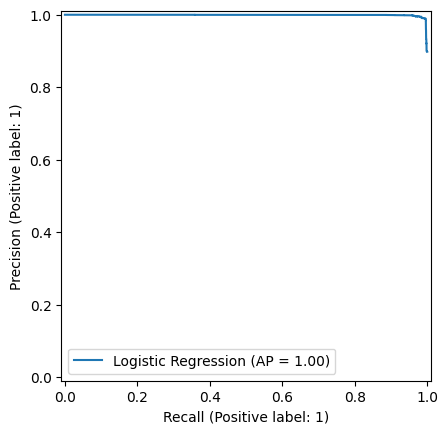

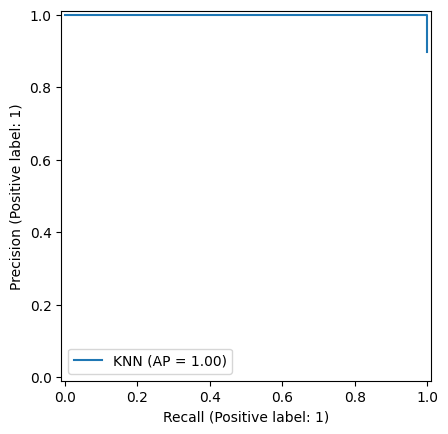

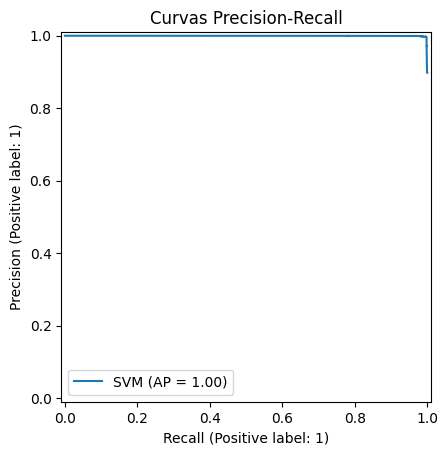

In [47]:
from sklearn.metrics import PrecisionRecallDisplay

for nombre, y_prob in probabilidades.items():

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=nombre
    )

plt.title(
    "Curvas Precision-Recall"
)

plt.show()

15. Comparar tiempos

In [48]:
resultados_df[
    [
        "Modelo",
        "Tiempo entrenamiento",
        "Tiempo predicción"
    ]
]

,Modelo,Tiempo entrenamiento,Tiempo predicción
0,Decision Tree Baseline,NaN,NaN
1,Random Forest,4.548698,0.201508
2,Logistic Regression,3.925369,0.020992
3,KNN,0.157614,15.919036
4,SVM,924.609392,5.381365


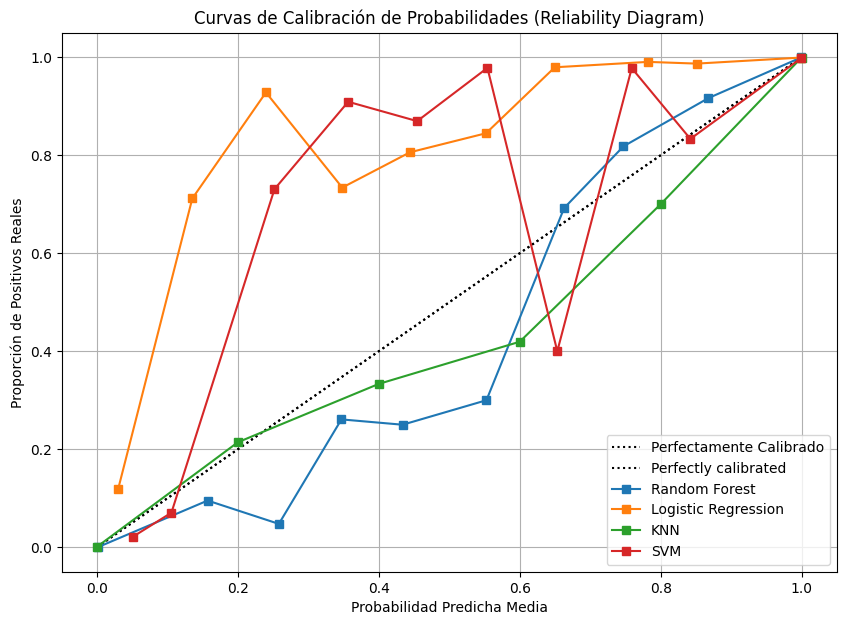

In [53]:
# ==========================================
# 6. CURVAS DE CALIBRACIÓN DE PROBABILIDADES
# ==========================================
fig, ax = plt.subplots(figsize=(10, 7))

# Generación de curva perfecta ideal (Diagonal de 45 grados)
ax.plot([0, 1], [0, 1], "k:", label="Perfectamente Calibrado")

for nombre in modelos_entrenados.keys():
    CalibrationDisplay.from_predictions(
        y_test,
        probabilidades[nombre],
        name=nombre,
        ax=ax,
        n_bins=10
    )

plt.title("Curvas de Calibración de Probabilidades (Reliability Diagram)")
plt.xlabel("Probabilidad Predicha Media")
plt.ylabel("Proporción de Positivos Reales")
plt.grid(True)
plt.show()

=== TABLA DE COMPLEJIDAD TEMPORAL Y TIEMPOS DE COMPUTACIÓN ===
             Modelo  Tiempo entrenamiento  Tiempo predicción
Logistic Regression              6.468181           0.042740
      Random Forest              4.794221           0.227300
                SVM            963.471671           5.350192
                KNN              0.171177          20.958719


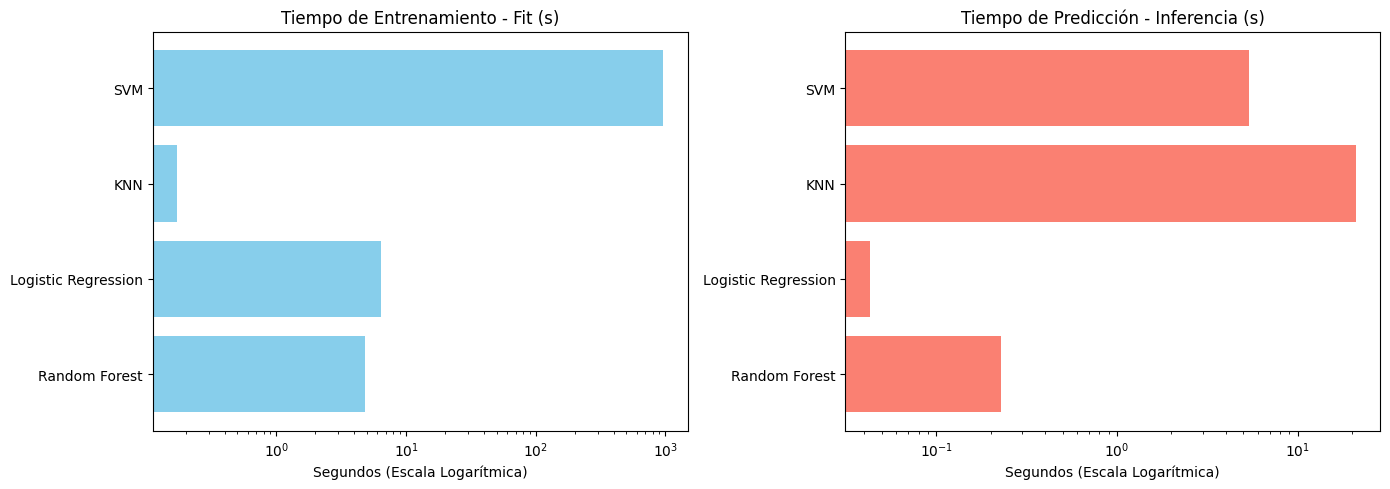

In [57]:
# ==========================================
# 7. COMPLEJIDAD TEMPORAL Y COSTOS
# ==========================================
tiempos_df = resultados_df[
    ["Modelo", "Tiempo entrenamiento", "Tiempo predicción"]
].copy()

# Ordenar por tiempo de predicción en inferencia real
tiempos_df = tiempos_df.sort_values(by="Tiempo predicción")
print("=== TABLA DE COMPLEJIDAD TEMPORAL Y TIEMPOS DE COMPUTACIÓN ===")
print(tiempos_df.to_string(index=False))

# Visualización comparativa de tiempos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(resultados_df["Modelo"], resultados_df["Tiempo entrenamiento"], color="skyblue")
axes[0].set_title("Tiempo de Entrenamiento - Fit (s)")
axes[0].set_xlabel("Segundos (Escala Logarítmica)")
axes[0].set_xscale("log")

axes[1].barh(resultados_df["Modelo"], resultados_df["Tiempo predicción"], color="salmon")
axes[1].set_title("Tiempo de Predicción - Inferencia (s)")
axes[1].set_xlabel("Segundos (Escala Logarítmica)")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()